# Introduction to Two mode Maser
## Author: Vineeth Thalakottoor

In [1]:
# Define the source path
SourcePath = '/media/HD2/Vineeth/PostDoc_Simulations/Github/PyOR_V1/PyOR_Combined/PyOR/Source_Doc'


# Add source path
import sys
sys.path.append(SourcePath)
import time
%matplotlib ipympl
import numpy as np

# Import PyOR package
from PyOR_QuantumSystem import QuantumSystem as QunS
from PyOR_Hamiltonian import Hamiltonian
from PyOR_DensityMatrix import DensityMatrix
from PyOR_QuantumObject import QunObj
from PyOR_HardPulse import HardPulse
from PyOR_Basis import Basis
from PyOR_Evolution import Evolutions
from PyOR_Plotting import Plotting
import PyOR_SignalProcessing as Spro
from PyOR_Relaxation import RelaxationProcess

import time
import datetime
import os
import sys
path = os.getcwd()

In [2]:
# Folder Creation

# Print simulation starting time
print("Simulation start time: ",datetime.datetime.now())

#--------------------------
# Automatic Folder Generator
#--------------------------
folder_number = 1 # First folder generated to save data
while True:
    try:
        folder = path + "/" + str(folder_number) # path is current directory
        os.mkdir(folder)
        break
    except OSError as err:
        folder_number = folder_number + 1 

#--------------------------        
# Save parameter information
#--------------------------
save_file = open(folder + "/info.txt", "a")       
print(f"folder = {folder}")
save_file.write(f"folder = {folder}")

Simulation start time:  2025-05-13 16:46:36.889487
folder = /media/HD2/Vineeth/PostDoc_Simulations/Github/PyOR_V1/PyOR_Combined/PyOR/Examples/Nonlinear_NMR/Maser/1


112

In [3]:
#--------------------------
# Define Spin System
#--------------------------
save_file.write(f"\n--------------") 

Spin_list = {"A" : "H1", "B" : "H1"}; save_file.write(f"\nSpin_list = {Spin_list}")

QS = QunS(Spin_list,PrintDefault=False)

# initialize the system
QS.Initialize()

In [4]:
#--------------------------
# Set parameters
#--------------------------

# Master Equation
QS.PropagationSpace = "Hilbert"; save_file.write(f"\nPropagationSpace = {QS.PropagationSpace}"); print(f"\nPropagationSpace = {QS.PropagationSpace}")
#QS.MasterEquation = "Lindblad" ; save_file.write(f"\nMasterEquation = {QS.MasterEquation}"); print(f"\nMasterEquation = {QS.MasterEquation}")
QS.MasterEquation = "Redfield" ; save_file.write(f"\nMasterEquation = {QS.MasterEquation}"); print(f"\nMasterEquation = {QS.MasterEquation}")

# B0 Field in Tesla, Static Magnetic field (B0) along Z
QS.B0 = 1.39
save_file.write(f"\nB0 = {QS.B0 =:0.3F}")

save_file.write(f"\n--------------"); print(f"\n--------------")
# Offset Frequency in rotating frame (Hz)
QS.OFFSET["A"] = 10.0  
QS.OFFSET["B"] = 45.0  
save_file.write(f"\nOFFSET0 = {QS.OFFSET}")

# Define initial and final Spin Temperature
QS.I_spintemp["A"] = 0.001
QS.I_spintemp["B"] = 0.001

QS.F_spintemp["A"] = -0.001
QS.F_spintemp["B"] = -0.001
QS.Lindblad_Temp = -0.001

save_file.write(f"\nIspintemp = {QS.I_spintemp}")
save_file.write(f"\nFspintemp = {QS.F_spintemp}")
save_file.write(f"\nLindblad_Temp = {QS.Lindblad_Temp}")


# Relaxation Process
Relaxation_Dipolar = False
if Relaxation_Dipolar:
    QS.Rprocess = "Auto-correlated Dipolar Homonuclear Ernst" 
    QS.RelaxParDipole_tau = 10.0e-12 
    QS.Dipole_Pairs = [("A","B")] # Define paris of spins coupled by dipolar interaction
    QS.RelaxParDipole_bIS = [15.0e3]
else:
    QS.Rprocess = "Phenomenological"
    QS.R1 = 1.0
    QS.R2 = 1.0

save_file.write(f"\nRprocess = {QS.Rprocess}")
save_file.write(f"\nRelaxParDipole_tau = {QS.RelaxParDipole_tau}")
save_file.write(f"\nDipolePairs = {QS.Dipole_Pairs}")
save_file.write(f"\nRelaxParDipole_bIS = {QS.RelaxParDipole_bIS}")

# Radaition Damping
QS.Rdamping = True 
QS.RD_xi["A"] = 20
QS.RD_xi["B"] = 20

QS.RD_phase["A"] = 0 
QS.RD_phase["B"] = 0
save_file.write(f"\nRdamping = {QS.Rdamping}")
save_file.write(f"\nRD_xi = {QS.RD_xi}")
save_file.write(f"\nRD_phase = {QS.RD_phase}")

QS.Update()    


PropagationSpace = Hilbert

MasterEquation = Redfield

--------------
Rotating frame frequencies: {'A': -371855580.0, 'B': -371855580.0}
Offset frequencies: {'A': 10.0, 'B': 45.0}
Initial spin temperatures: {'A': 0.001, 'B': 0.001}
Final spin temperatures: {'A': -0.001, 'B': -0.001}
Radiation damping gain: {'A': 20, 'B': 20}
Radiation damping phase: {'A': 0, 'B': 0}

Rprocess = Phenomenological
RelaxParDipole_tau = 0.0
DipolePairs = []
RelaxParDipole_bIS = []


In [5]:
#--------------------------
# Generate Hamiltonians
#--------------------------          
save_file.write(f"\n--------------"); print(f"\n--------------")

# generate Larmor Frequencies
QS.print_Larmor = True
Ham = Hamiltonian(QS)

# Lab Frame Hamiltonian
Hz_lab = Ham.Zeeman()

# Rotating Frame Hamiltonian
Hz = Ham.Zeeman_RotFrame()


--------------
Larmor Frequency in MHz:  [-59.18266367 -59.18269867]


In [6]:
#--------------------------    
# Initialize Density Matrix
#--------------------------
DM = DensityMatrix(QS,Ham)

# High Temperature
HT_approx = False

# Initial Density Matrix
rho_in = DM.EquilibriumDensityMatrix(QS.Ispintemp,HT_approx)

# Equlibrium Density Matrix
rhoeq = DM.EquilibriumDensityMatrix(QS.Fspintemp,HT_approx)

Trace of density matrix =  1.0
Trace of density matrix =  1.0


In [7]:
#--------------------------    
# Initial Pulse
#--------------------------

HardP = HardPulse(QS)

save_file.write(f"\n--------------"); print(f"\n--------------") 

flip_angle1 = 179.0 # Flip angle Spin 1 (or 2 and 3)
save_file.write(f"\nflip_angle1 = {flip_angle1}")

rho = HardP.Rotate_Pulse(rho_in,flip_angle1,QS.Ay+QS.By) 


--------------


In [8]:
#--------------------------
# Evolution
#--------------------------
save_file.write(f"\n--------------"); print(f"\n--------------") 

QS.AcqDT = 0.0001 
QS.AcqAQ = 20.0 
QS.OdeMethod = 'DOP853' ; 
QS.PropagationMethod = "ODE Solver" # "ODE Solver Lindblad" ; 
save_file.write(f"\nAcqDT = {QS.AcqDT }")
save_file.write(f"\nAcqAQ = {QS.AcqAQ }")
save_file.write(f"\nOdeMethod = {QS.OdeMethod }")
save_file.write(f"\nPropagationMethod = {QS.PropagationMethod }")

EVol = Evolutions(QS,Ham)
EVol.Update()

start_time = time.time()
t, rho_t = EVol.Evolution(rho,rhoeq,Hz)
end_time = time.time()
timetaken = end_time - start_time
print("\nTotal time = %s seconds " % (timetaken)) 
save_file.write(f"\nSimulation Time = {timetaken}")

save_file.close()


--------------
Larmor Frequency in MHz:  [-59.18266367 -59.18269867]

Total time = 18.55273127555847 seconds 


In [9]:
#--------------------------
# Expectation value
#--------------------------

det = QS.Ap + QS.Bp 
deta = QS.Ap
detb = QS.Bp

det1 = QS.Az + QS.Bz
det1a = QS.Az
det1b = QS.Bz 

t, signal = EVol.Expectation(rho_t,det)
t, signala = EVol.Expectation(rho_t,deta)
t, signalb = EVol.Expectation(rho_t,detb)

t, signal1 = EVol.Expectation(rho_t,det1)
t, signal1a = EVol.Expectation(rho_t,det1a)
t, signal1b = EVol.Expectation(rho_t,det1b)

/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(<Figure size 1000x500 with 1 Axes>,
 <matplotlib.widgets.SpanSelector at 0x7f0f2aaeda00>)

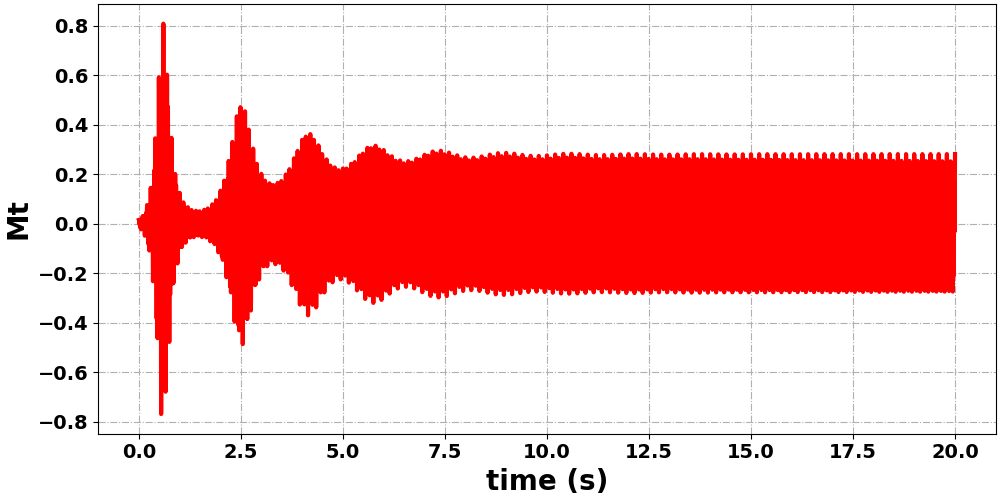

In [10]:
plot = Plotting(QS)
plot.PlotFigureSize = (10,5)
plot.PlotFontSize = 20
plot.Plotting_SpanSelector(t,signal,"time (s)","Mt","red", saveplt=True) 

/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


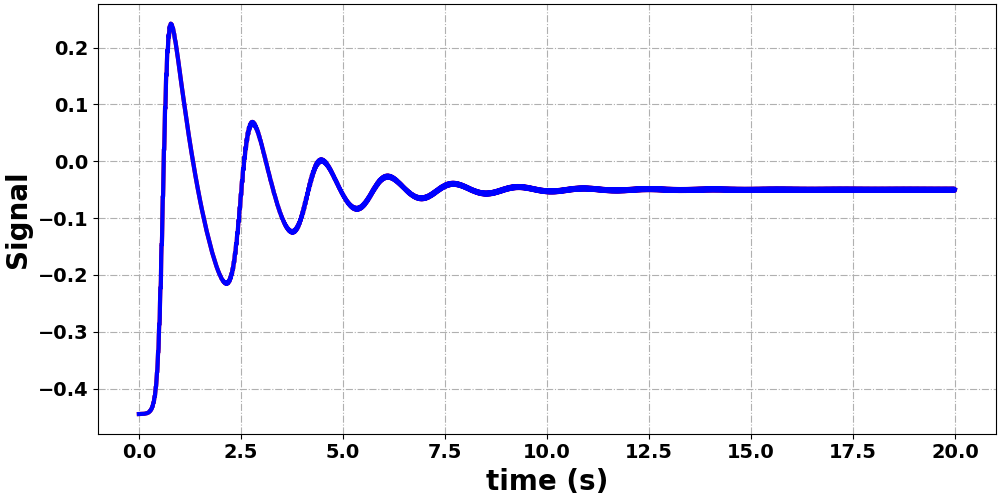

In [11]:
plot.PlottingMulti([t,t],[signal1a,signal1b],"time (s)","Signal",["red","blue"], saveplt=True)

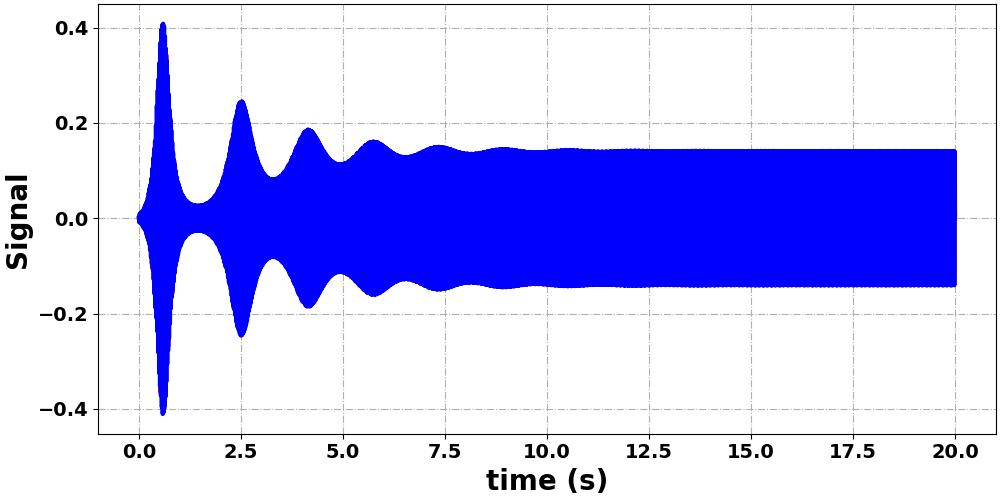

In [12]:
plot.PlottingMulti([t,t],[signala.imag,signalb.imag],"time (s)","Signal",["red","blue"], saveplt=True)

In [13]:
#-------------------------- 
# Save Data
#--------------------------

np.save(folder + '/time.npy', t) 
np.save(folder + '/signal.npy', signal)
np.save(folder + '/Mx_a.npy', signala) 
np.save(folder + '/Mx_b.npy', signalb) 

np.save(folder + '/Mz_a.npy', signal1a) 
np.save(folder + '/Mz_b.npy', signal1b)     